In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohamedkhairyelbanna/heartdiseasetrain-test/HeartDiseaseTrain-Test.csv


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"/kaggle/input/datasets/mohamedkhairyelbanna/heartdiseasetrain-test/HeartDiseaseTrain-Test.csv")

In [4]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1025, 14)

First 5 rows:


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [5]:
print("Missing values in Max_heart_rate column :", df['Max_heart_rate'].isnull().sum())

Missing values in Max_heart_rate column : 0


In [6]:
print("Descriptive Statistics for Max_heart_rate:")
print(df['Max_heart_rate'].describe())

Descriptive Statistics for Max_heart_rate:
count    1025.000000
mean      149.114146
std        23.005724
min        71.000000
25%       132.000000
50%       152.000000
75%       166.000000
max       202.000000
Name: Max_heart_rate, dtype: float64


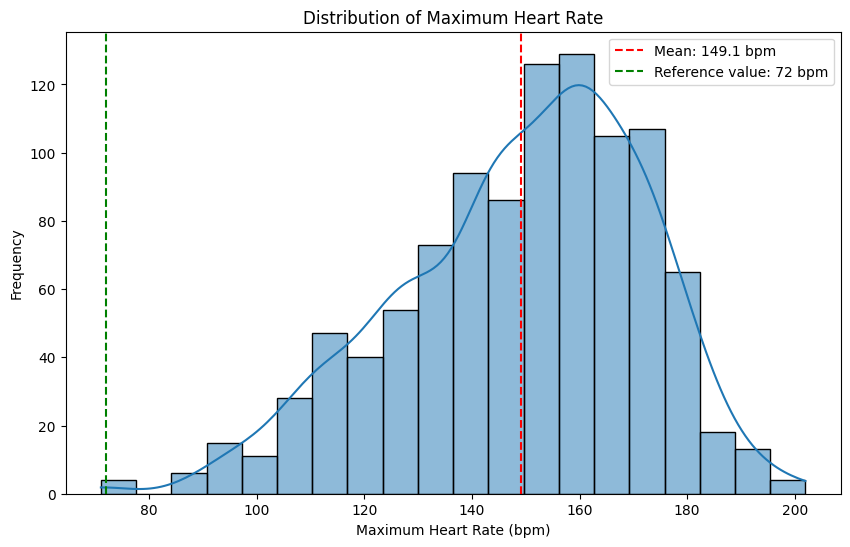

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Max_heart_rate'], kde=True)
plt.axvline(df['Max_heart_rate'].mean(),color="red",linestyle="--",label=f"Mean: {df['Max_heart_rate'].mean():.1f} bpm")
plt.axvline(72,color="green",linestyle="--",label="Reference value: 72 bpm")
plt.title("Distribution of Maximum Heart Rate")
plt.xlabel("Maximum Heart Rate (bpm)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [8]:
sample_mean = df['Max_heart_rate'].mean()
sample_std=df['Max_heart_rate'].std()
n = len(df['Max_heart_rate'])
null_hypothesis_value = 72

In [9]:
t_statistic = (sample_mean - null_hypothesis_value) / (sample_std / np.sqrt(n))
degrees_of_freedom = n - 1
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), degrees_of_freedom))

In [10]:
t_statistic_scipy, p_value_scipy = stats.ttest_1samp(df['Max_heart_rate'], null_hypothesis_value)

In [11]:
print("--- ONE-SAMPLE T-TEST RESULTS ---")
print(f"Sample size (n): {n}")
print(f"Sample mean: {sample_mean:.2f} bpm")
print(f"Sample standard deviation: {sample_std:.2f} bpm")
print(f"Null hypothesis value: {null_hypothesis_value} bpm")
print(f"T-statistic (manual calculation): {t_statistic:.4f}")
print(f"T-statistic (scipy calculation): {t_statistic_scipy:.4f}")
print(f"P-value (manual calculation): {p_value:.10f}")
print(f"P-value (scipy calculation): {p_value_scipy:.10f}")
print(f"Degrees of freedom: {degrees_of_freedom}")

--- ONE-SAMPLE T-TEST RESULTS ---
Sample size (n): 1025
Sample mean: 149.11 bpm
Sample standard deviation: 23.01 bpm
Null hypothesis value: 72 bpm
T-statistic (manual calculation): 107.3149
T-statistic (scipy calculation): 107.3149
P-value (manual calculation): 0.0000000000
P-value (scipy calculation): 0.0000000000
Degrees of freedom: 1024


In [12]:
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, degrees_of_freedom)
print(f"Critical t-value (α=0.05, two-tailed): ±{t_critical:.4f}")

Critical t-value (α=0.05, two-tailed): ±1.9623


In [13]:
if p_value < alpha:
    print("\nDecision: REJECT the null hypothesis")
    print("Conclusion: There is sufficient evidence to conclude that the mean maximum heart rate")
    print("is significantly different from 72 bpm at the 5% significance level.")
else:
    print("\nDecision: FAIL TO REJECT the null hypothesis")
    print("Conclusion: There is insufficient evidence to conclude that the mean maximum heart rate")
    print("is significantly different from 72 bpm at the 5% significance level.")


Decision: REJECT the null hypothesis
Conclusion: There is sufficient evidence to conclude that the mean maximum heart rate
is significantly different from 72 bpm at the 5% significance level.


In [14]:
confidence_interval = stats.t.interval(0.95,degrees_of_freedom,loc=sample_mean,scale=sample_std / np.sqrt(n))
print(f"\n95% Confidence Interval: "f"({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")


95% Confidence Interval: (147.70, 150.52)


In [15]:
d = (sample_mean - null_hypothesis_value) / sample_std
print(f"Effect Size (Cohen's d): {d:.3f}")

Effect Size (Cohen's d): 3.352


In [16]:
if abs(d) < 0.2:
    effect_size_interpretation = "negligible"
elif abs(d) < 0.5:
    effect_size_interpretation = "small"
elif abs(d) < 0.8:
    effect_size_interpretation = "medium"
else:
    effect_size_interpretation = "large"
print(f"This represents a {effect_size_interpretation} effect size.")

This represents a large effect size.


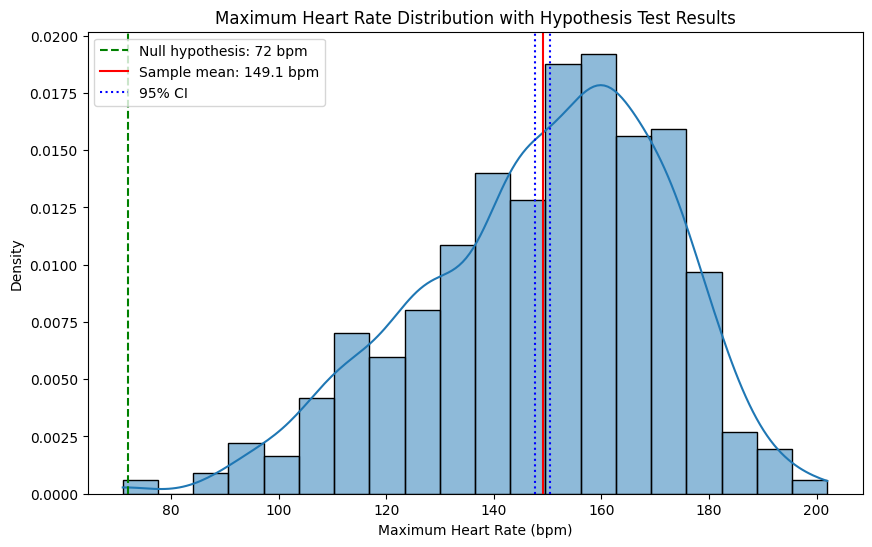

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Max_heart_rate'],kde=True,alpha=0.5,stat='density')
plt.axvline(null_hypothesis_value,color='green',linestyle='--',label=f'Null hypothesis: {null_hypothesis_value} bpm')
plt.axvline(sample_mean,color='red',linestyle='-',label=f'Sample mean: {sample_mean:.1f} bpm')
plt.axvline(confidence_interval[0],color='blue',linestyle=':',label='95% CI')
plt.axvline(confidence_interval[1],color='blue',linestyle=':')
plt.title('Maximum Heart Rate Distribution with Hypothesis Test Results')
plt.xlabel('Maximum Heart Rate (bpm)')
plt.ylabel('Density')
plt.legend()
plt.show()